<a href="https://colab.research.google.com/github/nimraa9090/AI-projects/blob/main/lab06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread("test.jpg", 0)

if img is None:
    print("Error: 'test.jpg' not found.")
else:
    print("Image loaded successfully.")

Image loaded successfully.


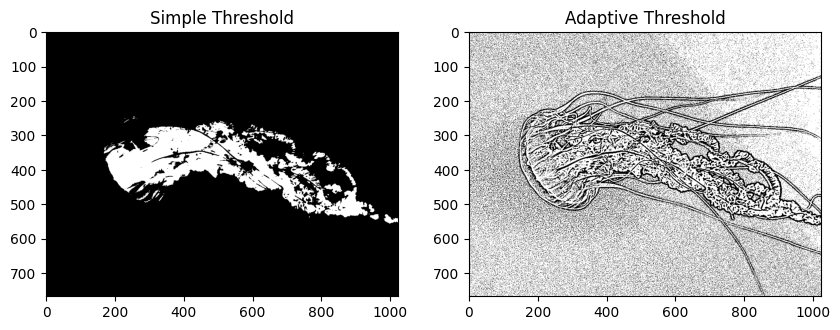

In [3]:
# Simple Thresholding
_, thresh_simple = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Adaptive Thresholding (better for uneven lighting)
thresh_adaptive = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 11, 2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(thresh_simple, cmap='gray'); plt.title("Simple Threshold")
plt.subplot(1, 2, 2); plt.imshow(thresh_adaptive, cmap='gray'); plt.title("Adaptive Threshold")
plt.show()

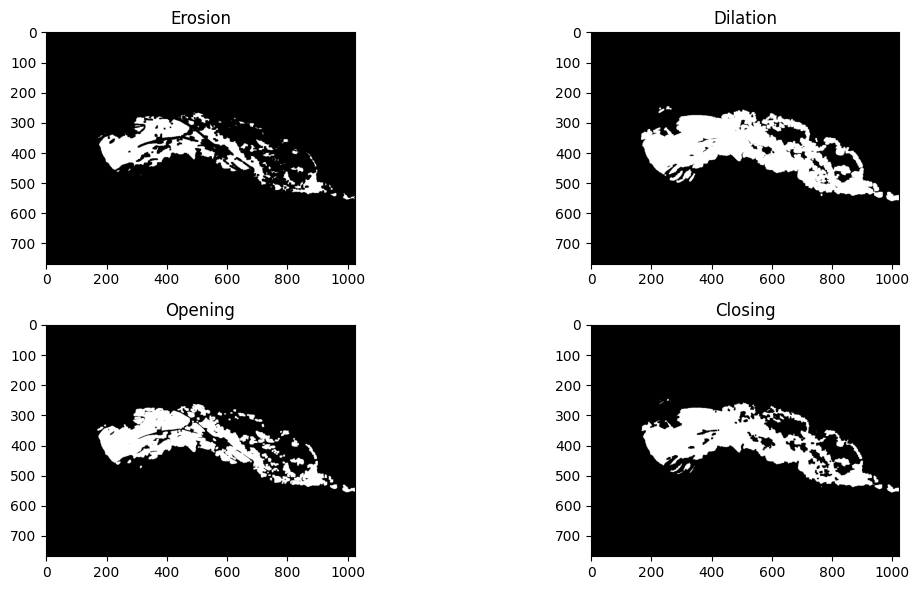

In [4]:
# Define a kernel for operations
kernel = np.ones((5,5), np.uint8)

# Erosion (removes small white noise)
erosion = cv2.erode(thresh_simple, kernel, iterations=1)

# Dilation (expands white regions)
dilation = cv2.dilate(thresh_simple, kernel, iterations=1)

# Opening (erosion followed by dilation - good for removing background noise)
opening = cv2.morphologyEx(thresh_simple, cv2.MORPH_OPEN, kernel)

# Closing (dilation followed by erosion - good for filling holes in objects)
closing = cv2.morphologyEx(thresh_simple, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1); plt.imshow(erosion, cmap='gray'); plt.title("Erosion")
plt.subplot(2, 2, 2); plt.imshow(dilation, cmap='gray'); plt.title("Dilation")
plt.subplot(2, 2, 3); plt.imshow(opening, cmap='gray'); plt.title("Opening")
plt.subplot(2, 2, 4); plt.imshow(closing, cmap='gray'); plt.title("Closing")
plt.tight_layout()
plt.show()